In [2]:
!pip install networkx

In [3]:
# Import numpy and pandas  libraries
import pandas as pd
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt

In [4]:
# Import the models from the sklearn.
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
df = pd.read_csv('observations_mammalia_global.csv')

In [6]:
# Check the datasets sample
df.head()

,id,observed_on,local_time_observed_at,latitude,longitude,positional_accuracy,public_positional_accuracy,image_url,license,geoprivacy,taxon_geoprivacy,scientific_name,common_name,taxon_id
0,128984633,2022-08-02,2022-08-02 00:40:00+10:00,-30.490071,151.639271,11,11,https://static.inaturalist.org/photos/21914219...,NaN,NaN,open,Phascolarctos cinereus,Koala,42983
1,129048796,2022-08-02,2022-08-02 07:55:55+10:00,-38.671312,146.164746,24,24,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,NaN,open,Wallabia bicolor,Swamp Wallaby,42973
2,129051266,2022-08-02,2022-08-02 00:20:13+02:00,43.119623,-7.678884,8,8,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY,NaN,open,Plecotus auritus,Brown Big-eared Bat,40416
3,129054418,2022-08-02,2022-08-02 00:26:13+02:00,50.686439,7.169781,6,6,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,NaN,NaN,Erinaceus europaeus,Common Hedgehog,43042
4,129076855,2022-08-02,2022-08-02 13:32:23+12:00,-40.949812,174.971092,5,5,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,open,Arctocephalus forsteri,New Zealand Fur Seal,41752


In [7]:
# For check the shape or size of the dataset.
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1648194, 14)
          id observed_on     local_time_observed_at   latitude   longitude  \
0  128984633  2022-08-02  2022-08-02 00:40:00+10:00 -30.490071  151.639271   
1  129048796  2022-08-02  2022-08-02 07:55:55+10:00 -38.671312  146.164746   
2  129051266  2022-08-02  2022-08-02 00:20:13+02:00  43.119623   -7.678884   
3  129054418  2022-08-02  2022-08-02 00:26:13+02:00  50.686439    7.169781   
4  129076855  2022-08-02  2022-08-02 13:32:23+12:00 -40.949812  174.971092   

   positional_accuracy  public_positional_accuracy  \
0                   11                          11   
1                   24                          24   
2                    8                           8   
3                    6                           6   
4                    5                           5   

                                           image_url   license geoprivacy  \
0  https://static.inaturalist.org/photos/21914219...       NaN        NaN   
1  https://inaturalist-

In [8]:
print(df.columns)

Index(['id', 'observed_on', 'local_time_observed_at', 'latitude', 'longitude',
       'positional_accuracy', 'public_positional_accuracy', 'image_url',
       'license', 'geoprivacy', 'taxon_geoprivacy', 'scientific_name',
       'common_name', 'taxon_id'],
      dtype='object')


In [9]:
# Rename columns to match our ML pipeline
df = df.rename(columns={
    'scientific_name': 'species',
    'observed_on': 'timestamp'
})

# Select required columns
df = df[['species', 'latitude', 'longitude', 'timestamp']]
df.dropna(inplace=True)

print("Dataset after preprocessing:")
print(df.head())


Dataset after preprocessing:
                  species   latitude   longitude   timestamp
0  Phascolarctos cinereus -30.490071  151.639271  2022-08-02
1        Wallabia bicolor -38.671312  146.164746  2022-08-02
2        Plecotus auritus  43.119623   -7.678884  2022-08-02
3     Erinaceus europaeus  50.686439    7.169781  2022-08-02
4  Arctocephalus forsteri -40.949812  174.971092  2022-08-02


In [10]:

# Feature Engineering & Normalization
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


In [11]:
# Normalize latitude & longitude
scaler = MinMaxScaler()
df[['latitude', 'longitude']] = scaler.fit_transform(df[['latitude', 'longitude']])

In [12]:
# Rename columns to match ML pipeline
df = df.rename(columns={
    'scientific_name': 'species',
    'observed_on': 'timestamp'
})

In [13]:
# Make sure 'species' column exists
if 'species' not in df.columns:
    df = df.rename(columns={'scientific_name': 'species', 'observed_on': 'timestamp'})

# Encode species
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

print(df[['species', 'species_encoded']].head())


                  species  species_encoded
0  Phascolarctos cinereus             3313
1        Wallabia bicolor             4738
2        Plecotus auritus             3420
3     Erinaceus europaeus             1239
4  Arctocephalus forsteri              199


In [14]:

# Random sample to reduce memory usage
df_sample = df.sample(n=50000, random_state=42)

X = df_sample[['latitude', 'longitude']]
y = df_sample['species_encoded']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (40000, 2) Test shape: (10000, 2)


In [16]:
# Run ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
# Train and test the model
df_sample = df.sample(n=20000, random_state=42) 
X = df_sample[['latitude', 'longitude']]
y = df_sample['species_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:

# Support Vector Machine (SVM)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("\n--- SVM Results ---")
print(classification_report(y_test, y_pred_svm))



--- SVM Results ---
              precision    recall  f1-score   support

          26       0.00      0.00      0.00         5
          28       0.00      0.00      0.00         1
          51       0.00      0.00      0.00         1
          53       0.00      0.00      0.00         1
          55       0.31      0.15      0.20        34
          57       0.00      0.00      0.00         1
          82       0.00      0.00      0.00         2
          84       0.00      0.00      0.00         1
          86       0.00      0.00      0.00         2
          88       0.00      0.00      0.00         6
          94       0.00      0.00      0.00         2
          96       0.00      0.00      0.00         3
         110       0.00      0.00      0.00         3
         112       0.00      0.00      0.00         1
         113       0.00      0.00      0.00         3
         118       0.00      0.00      0.00         1
         139       0.00      0.00      0.00         1
      

c:\Users\Mohnish\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mohnish\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mohnish\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

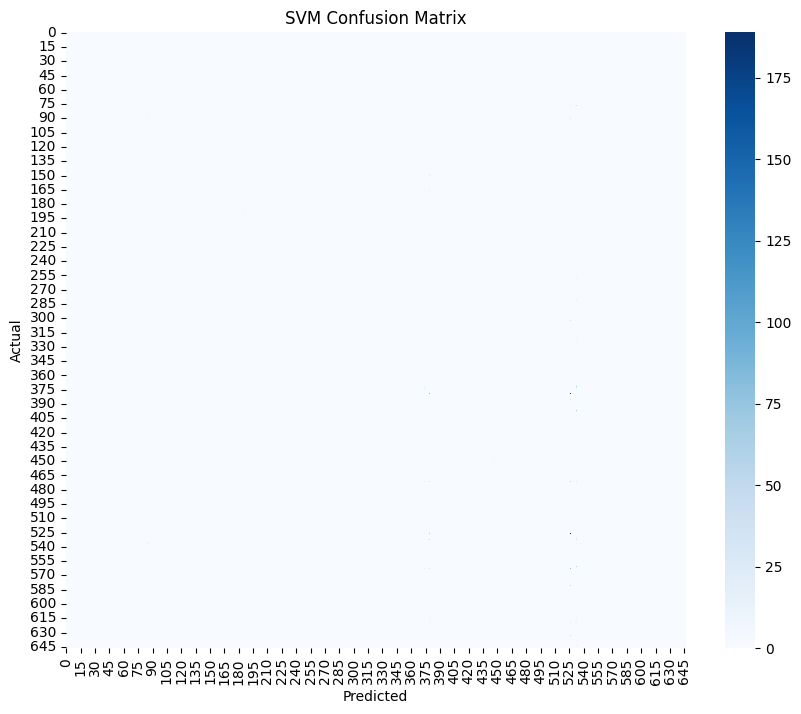

In [20]:
# Optional: Confusion Matrix for Random Forest
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()